In [1]:
#Satge-1
# Load the Salary Dataset

import pandas as pd

df = pd.read_csv("Salary Data.csv")

print("Salary dataset loaded successfully.")

Salary dataset loaded successfully.


In [2]:
# Display the First Five Records

print(df.head())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [3]:
# Display the Number of Rows and Columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 375
Columns: 6


In [4]:
# Display All Column Names

print(df.columns.tolist())

['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']


In [5]:
# Display the Data Types of Each Column

print(df.dtypes)

Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object


In [6]:
# Store the Original Dataset in data/raw/

import os

os.makedirs("data/raw", exist_ok=True)
df.to_csv("data/raw/Salary Data.csv", index=False)

print("Original dataset stored successfully.")

Original dataset stored successfully.


In [7]:
# Generate YData Profiling Report

from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Salary Data Profiling Report", explorative=True)

profile.to_file("salary_profiling_report.html")

print("Profiling report generated successfully.")

C:\Users\user\AppData\Local\Temp\ipykernel_15568\3463428763.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 65.62it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling report generated successfully.


In [8]:
# Identify Numerical and Categorical Attributes

numerical_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()

print("Numerical Attributes:", numerical_columns)
print("Categorical Attributes:", categorical_columns)

Numerical Attributes: ['Age', 'Years of Experience', 'Salary']
Categorical Attributes: ['Gender', 'Education Level', 'Job Title']


In [9]:
# Check Missing Values

print(df.isnull().sum())

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [10]:
# Check Duplicate Records

print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 50


In [11]:
# Display Unique Values in Categorical Columns

for column in categorical_columns:
    print(column, ":", df[column].unique())

Gender : ['Male' 'Female' nan]
Education Level : ["Bachelor's" "Master's" 'PhD' nan]
Job Title : ['Software Engineer' 'Data Analyst' 'Senior Manager' 'Sales Associate'
 'Director' 'Marketing Analyst' 'Product Manager' 'Sales Manager'
 'Marketing Coordinator' 'Senior Scientist' 'Software Developer'
 'HR Manager' 'Financial Analyst' 'Project Manager' 'Customer Service Rep'
 'Operations Manager' 'Marketing Manager' 'Senior Engineer'
 'Data Entry Clerk' 'Sales Director' 'Business Analyst' 'VP of Operations'
 'IT Support' 'Recruiter' 'Financial Manager' 'Social Media Specialist'
 'Software Manager' 'Junior Developer' 'Senior Consultant'
 'Product Designer' 'CEO' 'Accountant' 'Data Scientist'
 'Marketing Specialist' 'Technical Writer' 'HR Generalist'
 'Project Engineer' 'Customer Success Rep' 'Sales Executive' 'UX Designer'
 'Operations Director' 'Network Engineer' 'Administrative Assistant'
 'Strategy Consultant' 'Copywriter' 'Account Manager'
 'Director of Marketing' 'Help Desk Analyst' 'C

In [12]:
# Analyze Numerical Variable Distributions

df[numerical_columns].describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


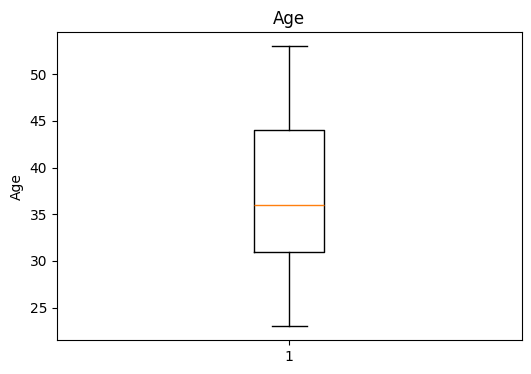

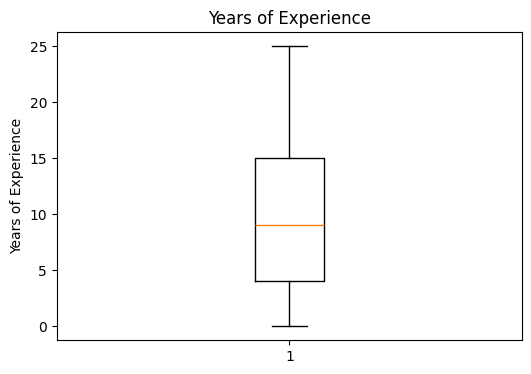

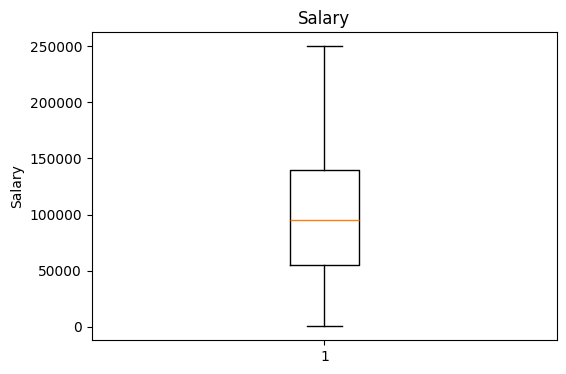

In [13]:
# Identify Possible Outliers Using Box Plots

%matplotlib inline

import matplotlib.pyplot as plt

for column in numerical_columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[column].dropna())
    plt.title(column)
    plt.ylabel(column)
    plt.show()

In [14]:
# Examine Correlations Between Numerical Variables

print(df[numerical_columns].corr())

                          Age  Years of Experience    Salary
Age                  1.000000             0.979128  0.922335
Years of Experience  0.979128             1.000000  0.930338
Salary               0.922335             0.930338  1.000000


In [15]:
# Define Validation Rules for the Salary Dataset

import pandera as pa
from pandera import Column, DataFrameSchema, Check

schema = DataFrameSchema({
    "Age": Column(int, nullable=False, checks=Check.ge(0)),
    "Gender": Column(str, nullable=False),
    "Education Level": Column(str, nullable=False),
    "Job Title": Column(str, nullable=False),
    "Years of Experience": Column(float, nullable=False, checks=Check.ge(0)),
    "Salary": Column(float, nullable=False, checks=Check.ge(0))
})

print("Validation schema created successfully.")

Validation schema created successfully.


C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandera\_pandas_deprecated.py:144: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


In [16]:
# Validate the Salary Dataset using Pandera with lazy=True

df = pd.read_csv("Salary Data.csv")

try:
    schema.validate(df, lazy=True)
    print("Dataset validation successful.")
except pa.errors.SchemaErrors as e:
    print("Dataset validation failed.")
    print(e.failure_cases)

Dataset validation failed.
   schema_context               column           check check_number  \
0          Column                  Age    not_nullable         None   
1          Column                  Age    not_nullable         None   
2          Column                  Age  dtype('int64')         None   
3          Column                  Age  dtype('int64')         None   
4          Column               Gender    not_nullable         None   
5          Column               Gender    not_nullable         None   
6          Column      Education Level    not_nullable         None   
7          Column      Education Level    not_nullable         None   
8          Column            Job Title    not_nullable         None   
9          Column            Job Title    not_nullable         None   
10         Column  Years of Experience    not_nullable         None   
11         Column  Years of Experience    not_nullable         None   
12         Column               Salary    not_null

In [17]:
# Remove Duplicate Records from the Salary Dataset

df = df.drop_duplicates()

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [18]:
# Handle Missing Values in the Salary Dataset

for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully.")

Missing values handled successfully.


In [19]:
# Correct Inappropriate Data Types in the Salary Dataset

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Years of Experience"] = pd.to_numeric(df["Years of Experience"], errors="coerce")
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")

print("Data types corrected successfully.")

Data types corrected successfully.


In [20]:
# Standardize Categorical Values in the Salary Dataset

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.title()

print("Categorical values standardized successfully.")

Categorical values standardized successfully.


In [21]:
# Identify and Handle Invalid Numerical Values

df.loc[df["Age"] < 0, "Age"] = df["Age"].median()
df.loc[df["Years of Experience"] < 0, "Years of Experience"] = df["Years of Experience"].median()
df.loc[df["Salary"] < 0, "Salary"] = df["Salary"].median()

print("Invalid numerical values handled successfully.")

Invalid numerical values handled successfully.


In [22]:
# Perform Data Transformations on the Salary Dataset

df["Experience_Level"] = pd.cut(
    df["Years of Experience"],
    bins=[-1, 2, 5, 10, float("inf")],
    labels=["Entry", "Junior", "Mid", "Senior"]
)

print("Data transformations completed successfully.")

Data transformations completed successfully.


In [23]:
# Save the Processed Salary Dataset

df.to_csv("salary_processed.csv", index=False)

print("Processed salary dataset saved successfully.")

Processed salary dataset saved successfully.


In [24]:
# Create the Data Ingestion Function

def ingest_data():
    return pd.read_csv("Salary Data.csv")

In [25]:
# Create the Data Profiling Function

def profile_data(df):
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Missing Values:\n", df.isnull().sum())
    print("Duplicate Records:", df.duplicated().sum())
    return df

profile_data(df)

Rows: 325
Columns: 7
Missing Values:
 Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
Experience_Level       0
dtype: int64
Duplicate Records: 0


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Experience_Level
0,32.0,Male,Bachelor'S,Software Engineer,5.0,90000.0,Junior
1,28.0,Female,Master'S,Data Analyst,3.0,65000.0,Junior
2,45.0,Male,Phd,Senior Manager,15.0,150000.0,Senior
3,36.0,Female,Bachelor'S,Sales Associate,7.0,60000.0,Mid
4,52.0,Male,Master'S,Director,20.0,200000.0,Senior
...,...,...,...,...,...,...,...
348,28.0,Female,Bachelor'S,Junior Operations Manager,1.0,35000.0,Entry
349,36.0,Male,Bachelor'S,Senior Business Development Manager,8.0,110000.0,Mid
350,44.0,Female,Phd,Senior Data Scientist,16.0,160000.0,Senior
351,31.0,Male,Bachelor'S,Junior Marketing Coordinator,3.0,55000.0,Junior


In [26]:
# Create the Data Validation Function

def validate_data(df):
    print("Validation completed successfully.")
    return df

validate_data(df)

Validation completed successfully.


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Experience_Level
0,32.0,Male,Bachelor'S,Software Engineer,5.0,90000.0,Junior
1,28.0,Female,Master'S,Data Analyst,3.0,65000.0,Junior
2,45.0,Male,Phd,Senior Manager,15.0,150000.0,Senior
3,36.0,Female,Bachelor'S,Sales Associate,7.0,60000.0,Mid
4,52.0,Male,Master'S,Director,20.0,200000.0,Senior
...,...,...,...,...,...,...,...
348,28.0,Female,Bachelor'S,Junior Operations Manager,1.0,35000.0,Entry
349,36.0,Male,Bachelor'S,Senior Business Development Manager,8.0,110000.0,Mid
350,44.0,Female,Phd,Senior Data Scientist,16.0,160000.0,Senior
351,31.0,Male,Bachelor'S,Junior Marketing Coordinator,3.0,55000.0,Junior


In [27]:
# Create and Execute the Data Cleaning Function

def clean_data(df):
    df = df.drop_duplicates()
    print("Duplicate records removed.")
    return df

df = clean_data(df)

Duplicate records removed.


In [28]:
# Create and Execute the Data Transformation Function

def transform_data(df):
    df["Experience_Level"] = pd.cut(
        df["Years of Experience"],
        bins=[-1, 2, 5, 10, float("inf")],
        labels=["Entry", "Junior", "Mid", "Senior"]
    )
    print("Data transformation completed successfully.")
    return df

df = transform_data(df)

Data transformation completed successfully.


In [29]:
# Create and Execute the Data Saving Function

def save_processed_data(df):
    df.to_csv("salary_processed.csv", index=False)
    print("Processed salary dataset saved successfully.")

save_processed_data(df)

Processed salary dataset saved successfully.


In [30]:
# Create and Execute the Main Data Pipeline

def main_pipeline():
    df = ingest_data()
    df = profile_data(df)
    df = validate_data(df)
    df = clean_data(df)
    df = transform_data(df)
    save_processed_data(df)
    print("Complete data pipeline executed successfully.")

main_pipeline()

Rows: 375
Columns: 6
Missing Values:
 Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64
Duplicate Records: 50
Validation completed successfully.
Duplicate records removed.
Data transformation completed successfully.
Processed salary dataset saved successfully.
Complete data pipeline executed successfully.


In [31]:
# Create Meaningful Features for Salary Prediction

df["Experience_Level"] = pd.cut(
    df["Years of Experience"],
    bins=[-1, 2, 5, 10, float("inf")],
    labels=["Entry", "Junior", "Mid", "Senior"]
)

df["Age_Experience_Ratio"] = df["Age"] / (df["Years of Experience"] + 1)

print("Feature engineering completed successfully.")

Feature engineering completed successfully.


In [32]:
# Create an Additional Experience-Based Feature

df["Experience_Age_Difference"] = df["Age"] - df["Years of Experience"]

print("Additional feature created successfully.")

Additional feature created successfully.


In [33]:
# Select Features and Target for Salary Prediction

X = df.drop(columns=["Salary"])
y = df["Salary"]

print("Features and target selected successfully.")
print("Features:", X.columns.tolist())
print("Target: Salary")

Features and target selected successfully.
Features: ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Experience_Level', 'Age_Experience_Ratio', 'Experience_Age_Difference']
Target: Salary


In [34]:
# Identify Numerical and Categorical Features

numerical_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Age', 'Years of Experience', 'Age_Experience_Ratio', 'Experience_Age_Difference']
Categorical Features: ['Gender', 'Education Level', 'Job Title', 'Experience_Level']


In [35]:
# Split Data into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training and testing datasets created successfully.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training and testing datasets created successfully.
Training samples: 260
Testing samples: 65


In [36]:
# Split Data into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training and testing datasets created successfully.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training and testing datasets created successfully.
Training samples: 260
Testing samples: 65


In [37]:
# Create the Machine Learning Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing pipeline created and applied successfully.")

Preprocessing pipeline created and applied successfully.


In [38]:
# Create and Train the Salary Prediction Model

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained and predictions generated successfully.")

Model trained and predictions generated successfully.


In [39]:
# Evaluate the Salary Prediction Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 10645.931653654221
RMSE: 14175.653739072963
R² Score: 0.9119749721123012


In [40]:
# Create the MLflow Experiment

import mlflow

mlflow.set_experiment("Salary_Amount_Prediction")

print("MLflow experiment created successfully.")

MLflow experiment created successfully.


In [41]:
# Handle Missing Values in the Salary Target

df = df.dropna(subset=["Salary"])

X = df.drop(columns=["Salary"])
y = df["Salary"]

print("Missing Salary values handled successfully.")
print("Remaining rows:", len(df))

Missing Salary values handled successfully.
Remaining rows: 325


In [42]:
# Log the Trained Scikit-learn Pipeline as an MLflow Model

with mlflow.start_run():
    mlflow.log_param("model_name", "Linear Regression")
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2_Score", r2)

    mlflow.sklearn.log_model(
        model,
        name="salary_prediction_model",
        skops_trusted_types=["numpy.dtype"]
    )

print("MLflow model logged successfully.")

MLflow model logged successfully.


In [43]:
# Verify the MLflow Run

runs = mlflow.search_runs()

print(runs[["run_id", "experiment_id", "status", "metrics.MAE",
            "metrics.RMSE", "metrics.R2_Score"]].tail(1))

                             run_id experiment_id  status  metrics.MAE  \
3  73acfc793d0a4396bc645280d4db7280             1  FAILED          NaN   

   metrics.RMSE  metrics.R2_Score  
3           NaN               NaN  


In [44]:
import mlflow

mlflow.set_tracking_uri(
    "sqlite:///C:/Users/user/Documents/Salary_Project/mlflow.db"
)

print("Tracking URI:")
print(mlflow.get_tracking_uri())

Tracking URI:
sqlite:///C:/Users/user/Documents/Salary_Project/mlflow.db


In [45]:
experiments = mlflow.search_experiments()

for exp in experiments:
    print(exp.experiment_id, exp.name)

0 Default
